# Time series data and models

## Model estimation and identification

- Fernando Corcuera and Diego the cat 


**The right model?**

- It is hard to model real world data and make inferences about it, the models rarely fits
- It always requrie judgement and evaluation not just computing stats and trying 1000 different models
- With monte carlo simulations we have a really intersting laboratory where we can test different identification test
- The process is :

1. Given a model, estimate its parameters
2. Given a set of models, determine the best


In [45]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

## Order determination: AR(2) example

- Autocorrelation: measures the total correlation between observations of different lags
- Partial autocorrelation: measures direct correlation between observations after removing the effect of intermidiate lags 

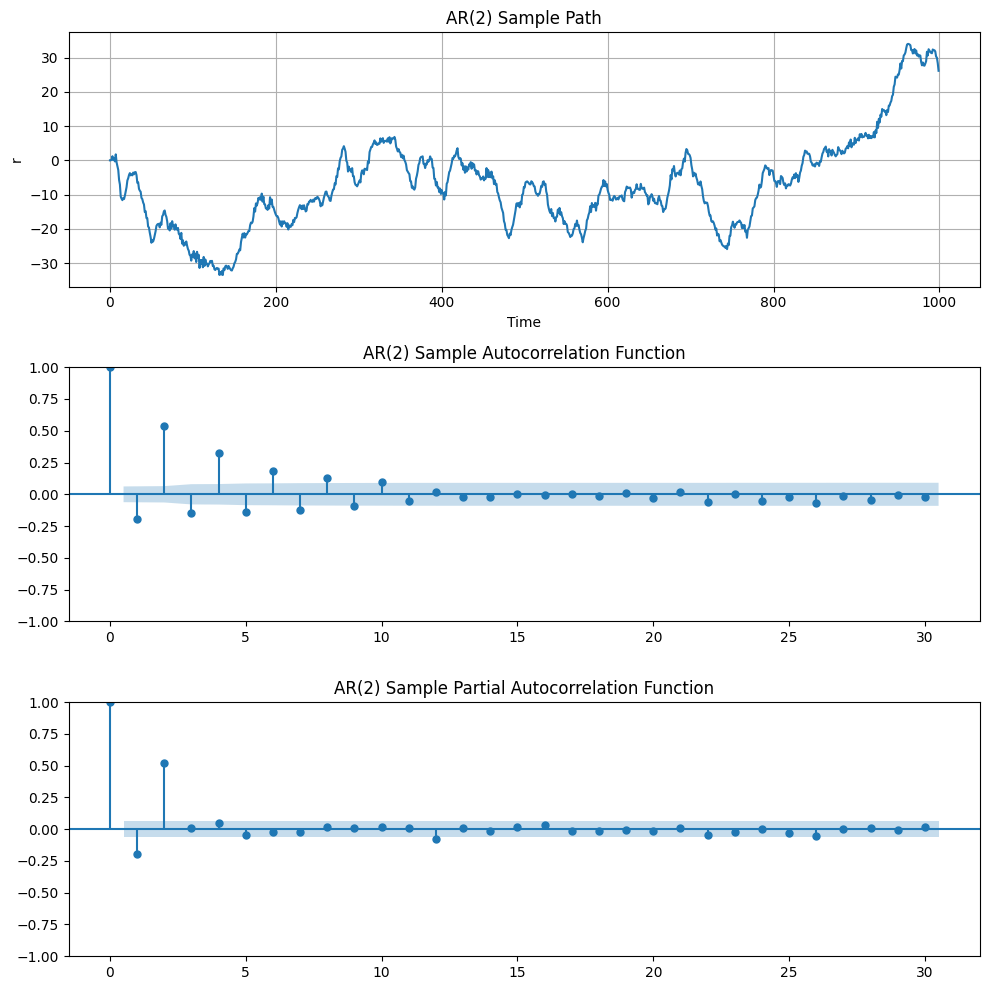

In [ ]:
c_0 = 0.001
c_1 = -0.1
c_2 = 0.5
sigma = 1
Nt = 1000
r = np.zeros(shape=Nt)
z = np.random.normal(size=Nt)

for i in range(2, Nt):

    r[i] = c_0 + c_1 * r[i - 1] + c_2 * r[i - 2] + sigma * z[i]

sample_path = np.cumsum(r)

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 10))

# AR PROCESS
axes[0].plot(sample_path)
axes[0].set_title("AR(2) Sample Path")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("r")
axes[0].grid(True)

# ACF
plot_acf(r, lags=30, ax=axes[1])
axes[1].set_title("AR(2) Sample Autocorrelation Function")

# PACF
plot_pacf(r, lags=30, ax=axes[2], method="ywm")

axes[2].set_title("AR(2) Sample Partial Autocorrelation Function")

plt.tight_layout()

plt.show()

## Model estimation AR(2) example:

- Autoregresive models can be viewed as linear regression models where the X features are the Y features lagged by n periods!
- For the process to be consistent, the regression residuals must be (approximately) an independent, uncorrelated white noise process.
- Overall a good time-series model should explain all predictable structure in the data. Therefore, the residuals should behave like white noise. If residuals remain autocorrelated, then the model has not captured all the information contained in past observations.

In [44]:
y = r[2:]
x1 = r[1:-1]
x2 = r[:-2]

X = pd.DataFrame({"x1": x1, "x2": x2})

X = sm.add_constant(X)
AR2model = sm.OLS(y, X).fit()
print(AR2model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.298
Model:                            OLS   Adj. R-squared:                  0.297
Method:                 Least Squares   F-statistic:                     211.1
Date:                Tue, 23 Jun 2026   Prob (F-statistic):           3.70e-77
Time:                        00:40:01   Log-Likelihood:                -1407.0
No. Observations:                 998   AIC:                             2820.
Df Residuals:                     995   BIC:                             2835.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0132      0.031      0.419      0.6

- Note how the linear regression has found similar coefficients (estimators) of the ar(2) process!
- **std err**: How much would the estimate vary if we repeated the simulation many times?
- **t-statistic** : How many standard errors away from zero is the stimate?
- **P-value**: <0.5 -> strong evidence that the coefficient is different than zero
- **Confidence interval**: A 95% confidence interval for the true coefficient.
- **R-squared**: 30% of the variation in r_t is explained by lagged returns
- **F-statistic**: Null hypothesis than both coefficents are 0
- **Durbin-Watson**: 2 -> no autocorrelation, <2 -> positive autocorrealtion, ...
- **jaque vera**: H0 that residuals are normal (0.76 no evidence against normality)

In [46]:
model = ARIMA(r, order=(2, 0, 0))
results = model.fit()

print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1409.151
Date:                Tue, 23 Jun 2026   AIC                           2826.302
Time:                        00:41:26   BIC                           2845.933
Sample:                             0   HQIC                          2833.763
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0230      0.055      0.420      0.675      -0.084       0.130
ar.L1         -0.0927      0.027     -3.441      0.001      -0.145      -0.040
ar.L2          0.5202      0.027     19.088      0.0

In [47]:
print("True parameters")
print(c_0, c_1, c_2)
print("AR(2) model: ")
print(AR2model.params)
print("ARIMA(2,0,0) model: ")
print(results.params)

True parameters
0.001 -0.1 0.5
AR(2) model: 
const    0.013185
x1      -0.092743
x2       0.521255
dtype: float64
ARIMA(2,0,0) model: 
[ 0.0229551  -0.09265591  0.5202122   0.97994957]


In [49]:
# what would happen if we fail to identify the process?
bad_model = ARIMA(r, order=(5, 0, 0))
bad_results = bad_model.fit()

print(bad_results.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(5, 0, 0)   Log Likelihood               -1406.818
Date:                Tue, 23 Jun 2026   AIC                           2827.637
Time:                        00:51:46   BIC                           2861.991
Sample:                             0   HQIC                          2840.694
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0229      0.056      0.412      0.681      -0.086       0.132
ar.L1         -0.0976      0.032     -3.095      0.002      -0.159      -0.036
ar.L2          0.4969      0.031     15.837      0.0

## Order determination: MA(2) Example

In [ ]:
mu = 0
sigma = 1.1
phi_1 = -0.1
phi_2 = 0.4
Nt = 1000
r = np.zeros(shape=Nt)
z = np.random.normal(size=Nt)

r[0] = mu + sigma * z[0]
r[1] = mu + sigma * z[1] + phi_1 * z[0]

r[2:] = mu + sigma * z[2:] + phi_1 * z[1:-1] + phi_2 * z[:-2]

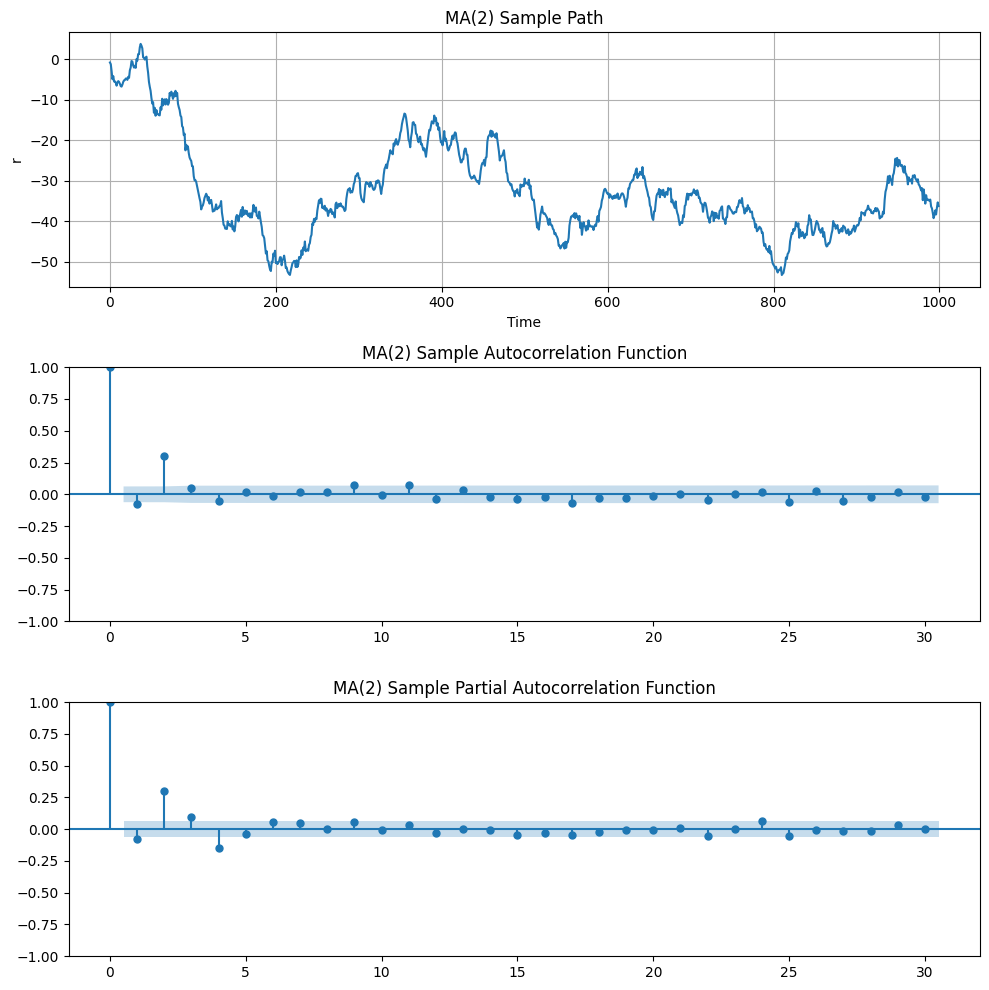

In [54]:
sample_path = np.cumsum(r)

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 10))

# MAPROCESS
axes[0].plot(sample_path)
axes[0].set_title("MA(2) Sample Path")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("r")
axes[0].grid(True)

# ACF
plot_acf(r, lags=30, ax=axes[1])
axes[1].set_title("MA(2) Sample Autocorrelation Function")

# PACF
plot_pacf(r, lags=30, ax=axes[2], method="ywm")

axes[2].set_title("MA(2) Sample Partial Autocorrelation Function")

plt.tight_layout()

plt.show()

## Model estimation MA(2):

In [55]:
MA2 = ARIMA(r, order=(0, 0, 2))
MA2_results = MA2.fit()

print(MA2_results.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 2)   Log Likelihood               -1499.515
Date:                Tue, 23 Jun 2026   AIC                           3007.029
Time:                        01:03:23   BIC                           3026.660
Sample:                             0   HQIC                          3014.491
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0358      0.045     -0.804      0.421      -0.123       0.052
ma.L1         -0.0891      0.029     -3.090      0.002      -0.146      -0.033
ma.L2          0.3887      0.030     12.760      0.0

In [ ]:
# why ACF cuts off in MA but decays in AR?
# why CAPF cuts off in AF but decays in AR?

# Real data is much harder: TSMC

In [56]:
ticker = "TSM"
start_date = "1999-12-31"
end_date = "2025-12-31"

tsm = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    interval="1d",
    auto_adjust=False,  # if true yahoo automtically modifies the open/close/low prices using adjustemnt factors
)
tsm.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,TSM,TSM,TSM,TSM,TSM,TSM
Date,,,,,,
1999-12-31,8.424754,17.059277,17.154051,16.798651,16.846037,428125
2000-01-03,8.869394,17.959627,18.007015,17.462067,17.912241,2062807
2000-01-04,8.927898,18.078094,18.670431,17.912241,17.959627,2557142
2000-01-05,8.986407,18.196564,18.362417,18.078094,18.243950,2295467
2000-01-06,8.611970,17.438372,17.793774,17.059277,17.770081,1539456


<Figure size 1000x500 with 0 Axes>

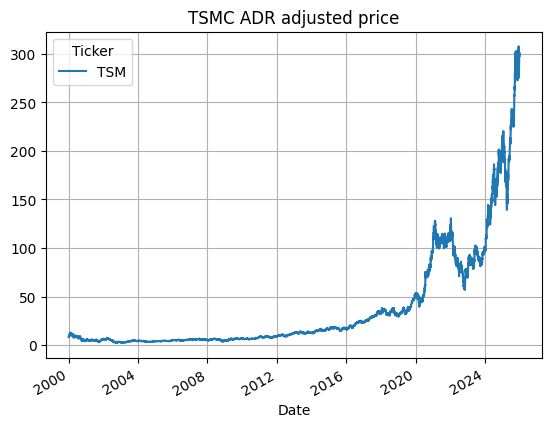

In [57]:
adj_prices = tsm["Adj Close"].dropna()
# this is how prices look over time, we can obersrve the AI boom int he last years
plt.figure(figsize=(10, 5))
adj_prices.plot(title="TSMC ADR adjusted price")
plt.grid()
plt.show()

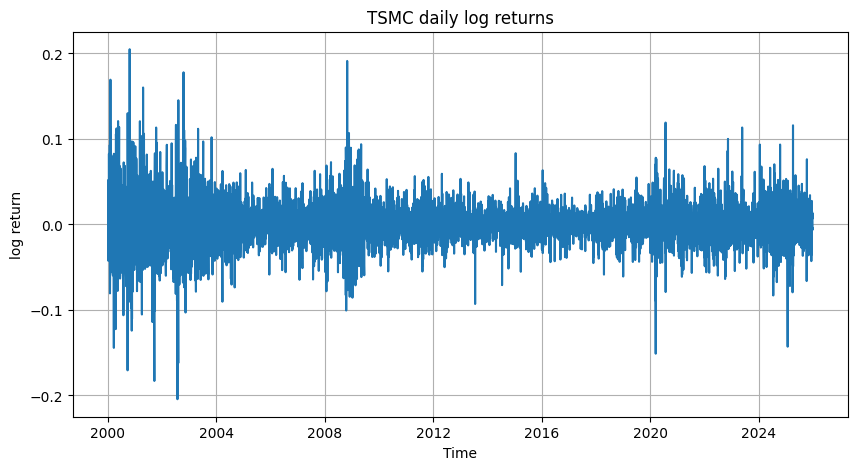

In [58]:
tsm["r"] = np.log(tsm["Adj Close"] / tsm["Adj Close"].shift(1))
tsm = tsm.dropna()
N = len(tsm["r"])

plt.figure(figsize=(10, 5))
plt.plot(tsm.index, tsm["r"])
plt.title("TSMC daily log returns")
plt.xlabel("Time")
plt.ylabel("log return")

plt.grid()
plt.show()

In [ ]:
q